# Reward-prediction evidence

**Purpose.** Keep the evidence for reward-prediction pipeline in one reproducible place. Evidence notebook, not a training notebook.

The model predicts immediate reward from the pre-action belief $b_t$ and current action $a_t$, and beats a constant-mean baseline on two held-out file splits. 

In [20]:
# move notebook to the root and check gpu availability
%cd /workspaces/tesis_v4

from pathlib import Path

# Run this notebook with the repository root as the working directory.
ROOT = Path.cwd()
if not (ROOT / 'src' / 'rwm').exists():
    raise RuntimeError('Open Jupyter from the repository root: jupyter lab --ip=0.0.0.0 --no-browser')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Change CURRENT_MODEL only; historical variants remain available for controlled comparisons.
MODEL_VARIANTS = {
    'current_beta0.1_seed42': ROOT / 'runs/component_refinement/02_vectorized_reward_anchor/beta0.1_seed42/checkpoint_best.pt',
    'current_beta0.1_seed43': ROOT / 'runs/component_refinement/02_vectorized_reward_anchor/beta0.1_seed43/checkpoint_best.pt',
    'corrected_beta0_seed42': ROOT / 'runs/component_refinement/01_corrected_reward_anchor/beta0.0_seed42/checkpoint_best.pt',
    'corrected_beta0.01_seed42': ROOT / 'runs/component_refinement/01_corrected_reward_anchor/beta0.01_seed42/checkpoint_best.pt',
    'corrected_beta0.1_seed42': ROOT / 'runs/component_refinement/01_corrected_reward_anchor/beta0.1_seed42/checkpoint_best.pt',
}
CURRENT_MODEL = 'current_beta0.1_seed42'
CHECKPOINT = MODEL_VARIANTS[CURRENT_MODEL]
assert CHECKPOINT.exists(), f'Missing checkpoint: {CHECKPOINT}'

plt.style.use('default')
print(f'PyTorch: {torch.__version__} | CUDA available: {torch.cuda.is_available()}')

/workspaces/tesis_v4
PyTorch: 2.7.0+cu128 | CUDA available: True


## Reproduce the anchor experiment

In [ ]:
# Writes a structured run with config, dataset manifest, metrics, probes, and checkpoints. 
!python scripts/evaluate_reward_prediction.py \
	--beta 0.1 --epochs 10 --batch-size 8 \
	--seed 42 --max-val-windows 256 \
	--cache-dir data/cache/rollout_frames_v1 \
	--out runs/component_refinement/02_vectorized_reward_anchor/beta0.1_seed42/reproduction_seed42

In [21]:
# Verify the trained checkpoint still produces distinct reward predictions for distinct actions.
!python scripts/evaluate_reward_prediction.py \
	--checkpoint {CHECKPOINT} \
	--out runs/evidence/action_probes/{CURRENT_MODEL}

Loading model...
/opt/conda/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
Loaded trained checkpoint: /workspaces/tesis_v4/runs/component_refinement/02_vectorized_reward_anchor/beta0.1_seed42/checkpoint_best.pt

Action probe (trained model, belief-fixed):
     all zeros: 0.255183
    full steer: 0.235486
      full gas: 0.247205
    full brake: 0.227788
Unique predictions: 4/4

Done. Results saved to runs/evidence/action_probes/current_beta0.1_seed42/action_probe_results.json


## Anchor results

Both runs use 256 bounded validation windows, 10 epochs, and $Beta=0$ (reward-only diagnostic). The baseline is the training-set constant mean reward.

In [22]:
results = pd.DataFrame([
    {'seed': 42, 'train_windows': 4040, 'val_windows': 256, 'val_mse': 0.4720, 'baseline_mse': 0.5634, 'time_s': 500},
    {'seed': 43, 'train_windows': 4304, 'val_windows': 256, 'val_mse': 0.5390, 'baseline_mse': 0.6295, 'time_s': 536},
])
results['model_baseline_ratio'] = results.val_mse / results.baseline_mse
results['improvement_pct'] = (1 - results.model_baseline_ratio) * 100
results.style.format({'val_mse': '{:.4f}', 'baseline_mse': '{:.4f}', 'model_baseline_ratio': '{:.3f}', 'improvement_pct': '{:.1f}%'})

,seed,train_windows,val_windows,val_mse,baseline_mse,time_s,model_baseline_ratio,improvement_pct
0,42,4040,256,0.4720,0.5634,500,0.838,16.2%
1,43,4304,256,0.5390,0.6295,536,0.856,14.4%


**Interpretation.** The anchor beats the constant baseline by about 14–16% across two seed-dependent file partitions. This is a valid starting point, not a final performance result: the current data is sparse and random-policy dominated.

## Review a manually driven reward trace

In [23]:
# Generate an aligned trace with the interactive command. 
# Close the game window or press Escape; the command saves the CSV.
!SDL_AUDIODRIVER=dummy rwm test-rwm-manually \
	{CHECKPOINT} \
  	--log-path runs/evidence/manual_traces/{CURRENT_MODEL}_session01.csv \
  	--fps 60

/opt/conda/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
Figure(700x350)
Saved 696 aligned reward pairs to runs/evidence/manual_traces/current_beta0.1_seed42_session01.csv


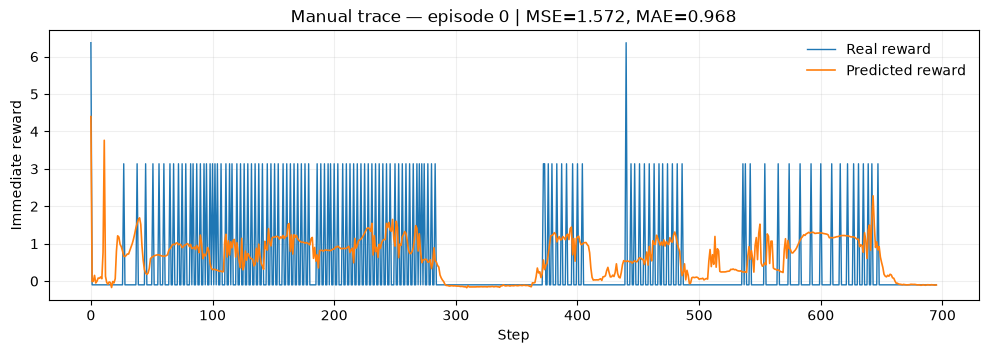

In [27]:
# Print the manual trace in a graphic

LOG_PATH = ROOT / 'runs' / 'evidence' / 'manual_traces' / (CURRENT_MODEL + '_session01.csv')

log = pd.read_csv(LOG_PATH)
episode_id = int(log.episode.max())
trace = log[log.episode == episode_id].copy()

if LOG_PATH.exists():
    episode_id = int(log.episode.iloc[-1])
    trace = log[log.episode == episode_id]
    mse = np.mean((trace.reward_true - trace.reward_pred) ** 2)
    mae = np.mean(np.abs(trace.reward_true - trace.reward_pred))

    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(trace.step, trace.reward_true, lw=1.0, label='Real reward')
    ax.plot(trace.step, trace.reward_pred, lw=1.2, label='Predicted reward')
    ax.set(title=f'Manual trace — episode {episode_id} | MSE={mse:.3f}, MAE={mae:.3f}',
           xlabel='Step', ylabel='Immediate reward')
    ax.legend(frameon=False)
    ax.grid(alpha=.2)
    plt.show()

## Manual-trace diagnostic

This is a qualitative distribution-shift check, **not** the thesis benchmark: the episode was human-driven and was not selected from the locked evaluation protocol.

We separate the first 50 frames (startup/camera confound) from steady driving. A reward event is any transition with real reward above the normal CarRacing baseline of `-0.1`.

In [32]:
# Raw comparison
STARTUP_STEPS = 50  # Change only when explicitly documenting a different protocol.

if LOG_PATH.exists():
    trace = log[log.episode == int(log.episode.iloc[-1])].copy()
    startup = trace.step < STARTUP_STEPS
    steady = ~startup
    reward_event = trace.reward_true > -0.1
    baseline = trace.reward_true <= -0.1

    def error_summary(name, mask):
        subset = trace.loc[mask]
        if subset.empty:
            return {'slice': name, 'n': 0, 'mse': np.nan, 'mae': np.nan,
                    'mean_true': np.nan, 'mean_pred': np.nan, 'mean_error': np.nan}
        error = subset.reward_pred - subset.reward_true
        return {
            'slice': name, 'n': len(subset),
            'mse': np.mean(error ** 2), 'mae': np.mean(np.abs(error)),
            'mean_true': subset.reward_true.mean(),
            'mean_pred': subset.reward_pred.mean(),
            'mean_error': error.mean(),  # negative = systematic underprediction
        }

    manual_diagnostic = pd.DataFrame([
        error_summary('all transitions', np.ones(len(trace), dtype=bool)),
        error_summary(f'startup (<{STARTUP_STEPS})', startup),
        error_summary('steady state', steady),
        error_summary('reward events, steady', steady & reward_event),
        error_summary('baseline -0.1, steady', steady & baseline),
    ])
    display(manual_diagnostic.style.format({
        'mse': '{:.3f}', 'mae': '{:.3f}', 'mean_true': '{:.3f}',
        'mean_pred': '{:.3f}', 'mean_error': '{:.3f}',
    }))

,slice,n,mse,mae,mean_true,mean_pred,mean_error
0,all transitions,696,1.572,0.968,0.472,0.636,0.164
1,startup (<50),50,1.339,0.832,0.224,0.695,0.471
2,steady state,646,1.590,0.979,0.491,0.631,0.140
3,"reward events, steady",387,2.149,1.152,0.887,0.639,-0.248
4,"baseline -0.1, steady",259,0.755,0.720,-0.100,0.619,0.719


In [33]:
# Positive-reward spikes in this trace are typically three steps apart; use the requested three-step causal target average.
SMOOTH_WINDOW = 3
positive_steps = trace.loc[trace.reward_true > 0, 'step'].to_numpy()
positive_gaps = np.diff(positive_steps)
assert len(positive_gaps), 'This trace has too few positive reward events for a rate diagnostic.'
print(f'Positive-reward spacing: median={np.median(positive_gaps):.0f}, IQR={np.quantile(positive_gaps, .25):.0f}–{np.quantile(positive_gaps, .75):.0f} steps; causal window={SMOOTH_WINDOW}.')

# Only the reward target is averaged: mean(r[t-2], r[t-1], r[t]); predictions retain their original scale.
reward_rate = trace.reward_true.rolling(SMOOTH_WINDOW, min_periods=SMOOTH_WINDOW).mean()
rate_valid = reward_rate.notna()
rate_steady = rate_valid & (trace.step >= STARTUP_STEPS)
rate_event = rate_steady & (reward_rate > -0.1)
rate_baseline = rate_steady & (reward_rate <= -0.1)

def rate_summary(name, mask):
    target = reward_rate.loc[mask]
    prediction = trace.loc[mask, 'reward_pred']
    error = prediction - target
    return {
        'slice': name, 'n': len(target),
        'mse': np.mean(error ** 2), 'mae': np.mean(np.abs(error)),
        'mean_true': target.mean(), 'mean_pred': prediction.mean(),
        'mean_error': error.mean(), 'correlation': target.corr(prediction),
    }

reward_rate_diagnostic = pd.DataFrame([
    rate_summary('steady, 3-step reward rate', rate_steady),
    rate_summary('reward events, steady rate', rate_event),
    rate_summary('baseline -0.1, steady rate', rate_baseline),
])
display(reward_rate_diagnostic.style.format({
    'mse': '{:.3f}', 'mae': '{:.3f}', 'mean_true': '{:.3f}', 'mean_pred': '{:.3f}',
    'mean_error': '{:.3f}', 'correlation': '{:.3f}',
}))

Positive-reward spacing: median=3, IQR=3–4 steps; causal window=3.


,slice,n,mse,mae,mean_true,mean_pred,mean_error,correlation
0,"steady, 3-step reward rate",646,0.318,0.382,0.491,0.631,0.140,0.509
1,"reward events, steady rate",477,0.218,0.308,0.701,0.681,-0.020,0.604
2,"baseline -0.1, steady rate",169,0.598,0.591,-0.100,0.490,0.590,0.117


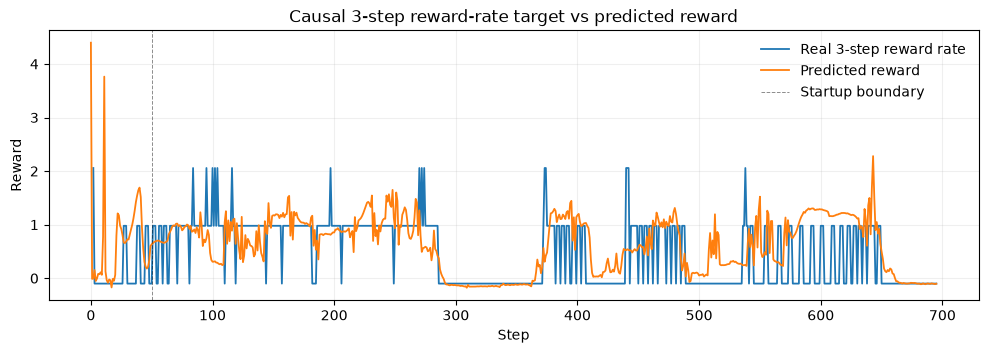

In [34]:
# The raw plot above remains unchanged; this second plot compares the three-step reward target with unnormalised predictions.
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(trace.step, reward_rate, lw=1.3, label='Real 3-step reward rate')
ax.plot(trace.step, trace.reward_pred, lw=1.3, label='Predicted reward')
ax.axvline(STARTUP_STEPS, color='black', lw=.7, ls='--', alpha=.45, label='Startup boundary')
ax.set(title='Causal 3-step reward-rate target vs predicted reward', xlabel='Step', ylabel='Reward')
ax.legend(frameon=False)
ax.grid(alpha=.2)
plt.show()